# 第1章：数字图像的获取和表示

## 编程实践：手写 Gamma 校正

> **参考来源**：本文 Gamma 校正公式与操作步骤参考知乎文章 [《重写版光的学习笔记(一)：应用方向RGB、HSV和Lab、sRGB、P3色彩空间概念》](https://zhuanlan.zhihu.com/p/707814472)，作者：@七月初。该文章详细讲解了 Gamma 校正的基本公式 $I_{out} = I_{in}^{\gamma}$、4 步操作流程，以及 Gamma 值对图像亮度的影响。

| 项目 | 说明 |
|------|------|
| 输入图片 | `lena.jpeg`（来自 Hands-on-CV（上海交通大学《动手学习计算机视觉》）参考资料第 2/5 章） |
| 手写核心 | 显式三重循环实现 Gamma 校正 |
| 允许调用 | 仅 `cv_imread` / `cv_imwrite` 图像读写 |
| 对比验证 | 与 OpenCV `cv2.LUT` 结果做数值误差对比 |
| 参考来源 | [知乎@七月初 - 光的学习笔记](https://zhuanlan.zhihu.com/p/707814472) |

## 一、学习目标

1. 数字图像是相机拍摄三维物理世界得到的平面投影，能说清每个像素值的物理含义。
2. 数码相机成像的 **ISP 管线** 包含哪些环节，每个环节在做什么。
3. 数字图像以**像素矩阵**方式记录，理解该矩阵的特点（离散、有限、量化、空间相关）。
4. 理解 Gamma 校正的公式、参数作用与典型应用场景。

> 本资料为掌握基础知识的学习指南，应以拓展学习和扎实积累为目的。学习完成后需能现场给出代码演示并回答概念理解与算法实现相关问题。

In [1]:
import sys
from pathlib import Path

# 向上查找项目根目录（含 utils.py），并加入 sys.path
ROOT = Path.cwd().resolve()
while not (ROOT / "utils.py").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("未找到项目根目录 utils.py")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import cv2
import matplotlib.pyplot as plt

from utils import cv_imread, cv_imwrite, set_random_seed, setup_plot_chinese, show_images, compare_results, plot_gamma_curve

setup_plot_chinese()
set_random_seed(42)
print(f"OpenCV 版本: {cv2.__version__}")
print(f"当前工作目录: {Path.cwd()}")
print(f"项目根目录: {ROOT}")
print("✅ 工具函数导入成功！")

OpenCV 版本: 5.0.0
当前工作目录: D:\CODE\Hands-On-Computer-Vision\图像处理基础\数字图像的获取和表示
项目根目录: D:\CODE\Hands-On-Computer-Vision
✅ 工具函数导入成功！


## 二、原理：数字图像是什么

### 2.1 从物理世界到数字矩阵

数字图像本质是一个 **二维矩阵**，每个元素称为 **像素（Pixel = Picture Element）**：

$$
\text{图像} = \text{一个 } H \text{ 行（高度）} \times W \text{ 列（宽度）的像素矩阵}
$$

**举个直观的例子**：
> 你用手机拍一张照片，其实就是把真实三维世界的光信号"压扁"到一个平面上，然后把平面切成 $W \times H$ 个小方格，每个小方格记录一个颜色值——这就是像素。一张 $512 \times 512$ 的 Lena 图，就是 $512$ 行 $\times$ $512$ 列 $= 262{,}144$ 个像素点。

### 2.2 灰度图 vs 彩色图

| 类型 | 每个像素包含 | 含义 | 取值范围 |
|------|-------------|------|----------|
| **灰度图** | 1 个数值 | 表示亮度（黑→白） | 通常是 `uint8`，即 `0~255` 的整数 |
| **彩色图** | 3 个数值 | OpenCV 默认按 **B→G→R** 顺序存储三通道 | 每个通道各 `0~255` |

> ⚠️ **零基础小提示**：为什么是 BGR 不是 RGB？
> 这是 OpenCV 历史遗留问题。早期 Windows 位图格式（BMP）用 BGR，OpenCV 诞生时沿用至今。所以：
> - `image[y, x, 0]` → **B**lue（蓝）
> - `image[y, x, 1]` → **G**reen（绿）
> - `image[y, x, 2]` → **R**ed（红）
>
> 而 `matplotlib.pyplot.imshow` 默认按 **RGB** 顺序显示，所以教程里显示前都会做 `[:, :, ::-1]` 把通道翻转一下。

### 2.3 一张照片的诞生：ISP 成像管线

按下快门后，相机内部会经历以下步骤，最终输出一张数字照片：

```
真实世界光线 → 镜头（聚焦）→ 光圈（控制光量）→ 快门（控制曝光时间）
    → CCD/CMOS 感光器（光→电模拟信号）→ ADC 模数转换（模拟→数字）
    → ISP 信号处理器 💻 → 最终的 JPEG 数字图像
```

ISP（Image Signal Processor）中最核心的处理环节：
1. **去马赛克（Demosaic）**：感光器每个像素只记录一种颜色（R/G/B），要通过插值"猜"出另外两个颜色值；
2. **白平衡**：补偿不同色温（暖黄/冷白）下的色偏；
3. **降噪**：抑制电路热噪声、高 ISO 带来的颗粒；
4. **色彩校正**：把传感器的原生色域映射到标准 sRGB；
5. **Gamma 校正**：补偿显示器的非线性（本章重点）；
6. **锐化**：补偿前面平滑造成的细节模糊。

### 2.4 像素矩阵的 4 个本质特点

| 特点 | 通俗解释 | 对算法的影响 |
|------|----------|--------------|
| **离散性** | 像素不是连续的，是一个个"小格子" | 必须处理边界（最外圈像素没有邻居） |
| **有限性** | 像素值不是任意精度，通常只有 0~255 共 256 个等级 | 计算后要 `clip` 或取整，否则会溢出/截断 |
| **量化误差** | 模拟信号 → 256 个离散等级会损失精度 | 多次运算会累积误差，要关注"误差传播" |
| **空间相关性** | 相邻像素通常"长得像"（同属一个物体） | 这就是滤波、插值、压缩等算法能成立的前提 |


findfont: Failed to find font weight medium, now using 400.


✅ 图像读取成功！
   · 形状 shape = (431, 789, 3) （高度 H，宽度 W，通道数 C）
   · 数据类型 dtype = uint8 （uint8 = 0~255 的无符号整数）
   · 像素总数量 = 340,059

🔍 左上角 (y=0, x=0) 处的像素值 = [ 54  58 114]
   解读：B= 54, G= 58, R=114

📊 整幅图的三通道统计：
   B(蓝)：min=  0, max=208, mean=62.6
   G(绿)：min=  4, max=211, mean=77.8
   R(红)：min= 25, max=255, mean=142.9


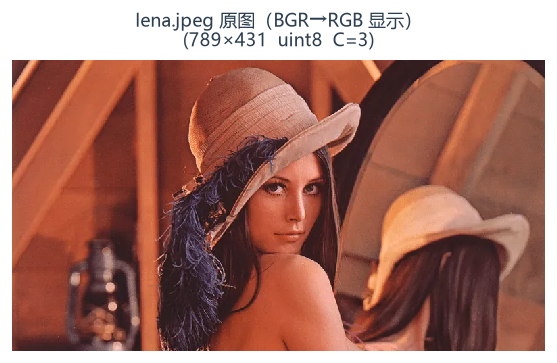

In [2]:
# ---------- 零基础直观演示：读取一张图并打印像素矩阵 ----------
demo_img = cv_imread("lena.jpeg", cv2.IMREAD_COLOR)
assert demo_img is not None, "读取 lena.jpeg 失败，请检查文件路径"
print(f"✅ 图像读取成功！")
print(f"   · 形状 shape = {demo_img.shape} （高度 H，宽度 W，通道数 C）")
print(f"   · 数据类型 dtype = {demo_img.dtype} （uint8 = 0~255 的无符号整数）")
print(f"   · 像素总数量 = {demo_img.shape[0] * demo_img.shape[1]:,}")
print()
print(f"🔍 左上角 (y=0, x=0) 处的像素值 = {demo_img[0, 0, :]}")
print(f"   解读：B={demo_img[0,0,0]:3d}, G={demo_img[0,0,1]:3d}, R={demo_img[0,0,2]:3d}")
print()
print(f"📊 整幅图的三通道统计：")
for ch, name in zip([0,1,2], ["B(蓝)", "G(绿)", "R(红)"]):
    arr = demo_img[:, :, ch]
    print(f"   {name}：min={arr.min():3d}, max={arr.max():3d}, mean={arr.mean():.1f}")

show_images([demo_img], ["lena.jpeg 原图（BGR→RGB 显示）"], show_info=True, figsize=(5, 5))

## 三、原理：Gamma 校正

### 3.1 为什么需要 Gamma 校正？——从人眼和显示器的"怪脾气"说起

你可能会问：**为什么不直接用 0~255 线性表示亮度？** 这涉及到两个关键事实：

1. **人眼对亮度的感知是非线性的**：暗部变化更容易察觉，亮部变化不敏感。
2. **CRT/LED 显示器的物理响应也是非线性的**：输入电压 V 和输出亮度 L 的关系近似为
   $L \propto V^{2.2}$（经典 CRT 显示器的 Gamma 值约为 2.2）。

如果直接把数字信号线性地送给显示器，暗部会显得"灰蒙蒙一片"——因为分配给暗部的比特数不够。而经过 **Gamma 校正（预加重）** 后，信号先做一次"反变换"，再叠加显示器的物理非线性，最终人眼看到的就是近似线性的亮度变化。

### 3.2 Gamma 校正的数学公式

Gamma 校正是对每个像素值独立做**幂函数**的非线性映射（逐像素、逐通道处理）：

$$
I_{out} = 255 \times \left( \frac{I_{in}}{255} \right) ^ {\frac{1}{\gamma}}
$$

**其中：**
- $I_{in} \in [0,255]$：输入像素值（先归一化到 $[0,1]$）
- $\gamma > 0$：Gamma 超参数，用户可调
- 结果再反归一化回 $[0,255]$ 并取整

### 3.3 一张图看懂 $\gamma$ 的影响（口诀：>1 变亮，<1 变暗）

| 情形 | 曲线形状 | 直观效果 |
|------|----------|----------|
| $\gamma > 1$ | 曲线下凹（向 1/x 弯曲） | 暗部被**拉伸**，整体图像**变亮** ☀️ |
| $\gamma = 1$ | 恒等直线 | 图像**完全不变** |
| $\gamma < 1$ | 曲线上凸（向 $\sqrt{x}$ 弯曲） | 暗部被**压缩**，整体图像**变暗** 🌙 |
| $\gamma = 2.2$ | — | sRGB 标准 / 传统显示器的默认 Gamma |

> 📌 **零基础小技巧**：不管公式多复杂，只记住一句话：
> **Gamma > 1 画面"洗白"、Gamma < 1 画面"压暗"。**
> 标准显示器用 2.2 补偿物理非线性。

### 3.4 Gamma 校正的基本公式

> 以下公式参考 [知乎@七月初 - 光的学习笔记](https://zhuanlan.zhihu.com/p/707814472)。

![Gamma 校正基本公式](ref_gamma_formula.png)

Gamma 校正的本质是对每个像素值做**幂函数**映射：

$$
I_{\text{out}} = I_{\text{in}}^{\gamma}
$$

**其中：**
- $I_{\text{in}}$ 是输入图像的像素值（通常归一化为 $0$ 到 $1$ 之间）
- $I_{\text{out}}$ 是经过 Gamma 校正后的输出像素值
- $\gamma$ 是 Gamma 值，决定了校正的强度

> **与 3.2 节公式的对应关系**：3.2 节的 $I_{out} = 255 \times (I_{in}/255)^{1/\gamma}$ 就是将此公式先归一化、做幂运算、再反归一化的完整形式。此处的 $\gamma$ 对应 3.2 节公式中的 $1/\gamma$（即编码 Gamma vs 解码 Gamma 的视角差异）。

### 3.5 实际操作步骤（4 步法）

![Gamma 校正实际操作步骤](ref_gamma_steps.png)

将上述公式应用到 8 位图像（像素值 $0 \sim 255$）时，需要经过以下 4 个步骤：

**步骤 1 — 归一化像素值**：

$$
I_{\text{in\_norm}} = \frac{I_{\text{in}}}{255}
$$

将 $[0, 255]$ 范围的整数像素值映射到 $[0, 1]$ 的浮点数，以便做幂运算。

**步骤 2 — 应用 Gamma 校正**：

$$
I_{\text{out\_norm}} = I_{\text{in\_norm}}^{\gamma}
$$

对归一化值做 $\gamma$ 次幂运算。$\gamma > 1$ 时图像变暗，$\gamma < 1$ 时图像变亮。

**步骤 3 — 反归一化**：

$$
I_{\text{out}} = I_{\text{out\_norm}} \times 255
$$

将结果从 $[0, 1]$ 映射回 $[0, 255]$。

**步骤 4 — 取整和限制范围**：

$$
I_{\text{out}} = \text{clip}(\text{round}(I_{\text{out}}), 0, 255)
$$

四舍五入为整数，并裁剪到 $[0, 255]$ 范围内，确保是有效的 8 位像素值。

> **本 notebook 的手写实现**正是按照这 4 步完成的：先除 255 归一化 → 幂运算 → 乘 255 反归一化 → 取整裁剪。

### 3.6 典型应用场景

- **显示器校准**：Windows/macOS 显示设置里的"Gamma 调整"就是这个。
- **暗部增强**：拍夜景时原图太暗，用 $\gamma = 2\sim3$ 提亮暗部（注意会放大噪声）。
- **摄影后期**：Lightroom/PS 里的"曲线工具"中间那个 S 曲线，本质就是局部 Gamma。
- **医学影像**：CT/MRI 图像常常需要在不同 Gamma 下观察软组织 vs 骨骼。

D:\CODE\Hands-On-Computer-Vision\utils.py:285: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
D:\CODE\Hands-On-Computer-Vision\utils.py:285: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
D:\python\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)
D:\python\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


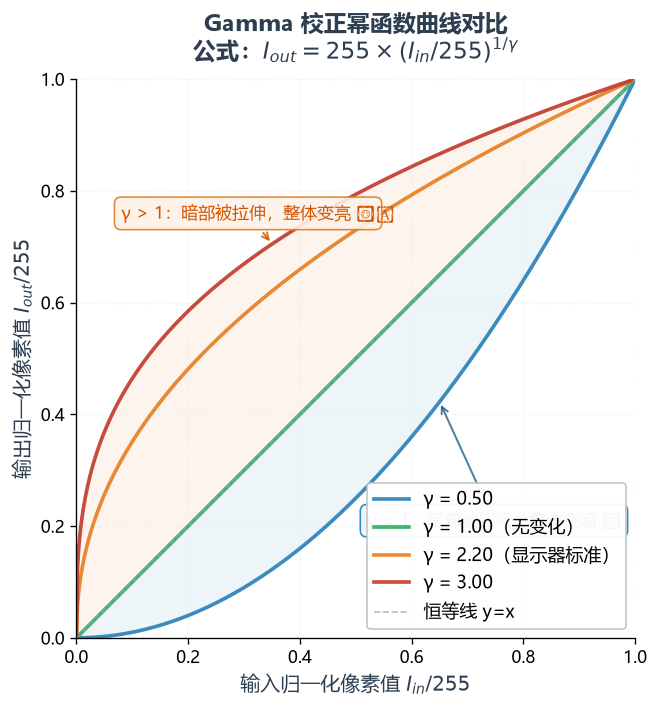

In [3]:
# ---------- 零基础直观图：不同 Gamma 的幂函数曲线 ----------
# 运行下面这行，你就能直观看到 gamma=0.5 / 1.0 / 2.2 / 3.0 的形状区别
plot_gamma_curve(gammas=(0.5, 1.0, 2.2, 3.0))

## 四、手写约束清单

> 老师要求：除 OpenCV 的图像读写函数外，其余代码全部自己手写，不能调用其他函数库。
>
> 🎓 **零基础为什么要手写三重循环？**
> 如果一开始就用 `np.power(img, 1/gamma)` 这种向量化写法，你只会"调库"，根本不理解算法在对**每个像素**做什么。
> 先手写逐像素循环搞清楚"每一步对哪个格子里的数做了什么运算"，之后工程里再用向量化/LUT 加速——这才是从"理解"到"高效"的正确路径。

| 类型 | 是否允许 | 说明 |
|------|:---:|------|
| `cv_imread` / `cv_imwrite` | ✅ | 图像读写 |
| Python 循环 / 条件 / 算术 | ✅ | 核心算法（必须手写三重循环，彻底吃透） |
| `np.zeros` 等数组分配 | ✅ | 仅用于开辟结果空间（不能用 `np.power` 等做运算） |
| `cv2.LUT` / `cv2.cvtColor` | ❌ | 属于图像处理函数，实现中不得使用（仅对比验证时可用） |
| `np.power` / `np.vectorize` | ❌ | 属于向量化函数，实现中不得使用 |
| `matplotlib` | ✅ | 仅用于可视化，不参与算法计算 |
| 与 OpenCV 的对比验证 | ✅ | 仅放在"验证"单元格，不属于手写实现 |

In [4]:
def gamma_correction_manual(image, gamma):
    """手写 Gamma 校正。

    参数
    ----
    image : np.ndarray
        输入 BGR 图像，形状 (H, W, 3)，dtype=uint8。
    gamma : float
        Gamma 值，大于 0。

    返回
    ----
    np.ndarray
        校正后的 uint8 图像。

    说明
    ----
    使用显式三重循环逐像素计算 I_out = 255 * (I_in / 255) ** (1 / gamma)，
    不调用 np.power / cv2.LUT 等向量化或库函数。
    """
    h, w, c = image.shape
    result = np.zeros((h, w, c), dtype=np.uint8)
    inv_gamma = 1.0 / gamma

    for y in range(h):
        for x in range(w):
            for ch in range(c):
                value = float(image[y, x, ch]) / 255.0
                corrected = value ** inv_gamma
                result[y, x, ch] = int(round(corrected * 255.0))
    return result

# 自测：3x3 小图像，gamma=1 时应保持原值不变
small = np.arange(27, dtype=np.uint8).reshape(3, 3, 3)
identity = gamma_correction_manual(small, 1.0)
assert np.array_equal(small, identity), "gamma=1 应保持原图不变"
print("✅ 自测通过：gamma=1 时输出与输入一致")

✅ 自测通过：gamma=1 时输出与输入一致


findfont: Failed to find font weight medium, now using 400.


  🔍 【Gamma 校正】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 0.498046    ✅ 优秀
  RMSE 均方根误差    = 0.705724    ✅ 优秀
  Max  最大绝对误差  = 1.000000    ✅ 优秀
  🎉 恭喜！误差仅来自 uint8 取整，手写实现与参考实现基本一致。



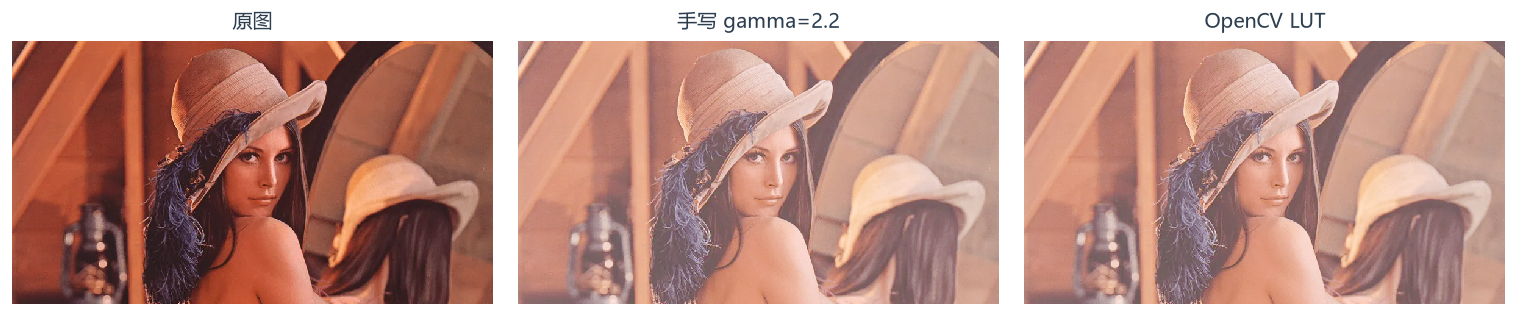

In [5]:
# 读取输入图像并执行手写 Gamma 校正
img = cv_imread("lena.jpeg", cv2.IMREAD_COLOR)
assert img is not None, "读取 lena.jpeg 失败"

gamma = 2.2
out = gamma_correction_manual(img, gamma)

# ---------- 与 OpenCV 对比验证（仅验证，不用于实现） ----------
lut = np.array([(i / 255.0) ** (1.0 / gamma) * 255.0 for i in range(256)], dtype=np.uint8)
ref = cv2.LUT(img, lut)
compare_results(out, ref, "Gamma 校正")

cv_imwrite("gamma_corrected.jpg", out)
show_images([img, out, ref], [f"原图", f"手写 gamma={gamma}", "OpenCV LUT"], figsize=(13, 4))

## 五、结果与参数分析

- 与 `cv2.LUT` 的参考结果对比，误差应只在 `±1` 个灰度级以内（由 `int(round(...))` 取整造成），MAE 接近 0。
- 可以尝试 `gamma=0.5 / 1.0 / 3.0`，观察图像变暗 / 不变 / 变亮。
- 三重循环在大图上较慢，这正是"手写实现"与工程上向量化实现之间的权衡：教学中先吃透逐像素逻辑，再理解为何工程代码会用查表（LUT）加速。

**易错点**
1. OpenCV 通道顺序是 **BGR** 而非 RGB。
2. 必须先归一化到 `[0,1]` 再做幂运算，最后反归一化回 `[0,255]`。
3. 用 `int(round(...))` 而不是 `int(...)`，减小截断误差。
4. JPEG 是有损压缩，保存后再读取可能引入微小像素差异。

## 六、科研规范小结

1. **可复现**：所有随机操作固定种子；本页无随机量，但统一调用 `set_random_seed(42)` 作为约定。
2. **函数化**：核心逻辑封装为带 docstring 的函数，便于复用和测试。
3. **对比验证**：手写实现必须与可信的库实现做数值对比，量化误差而非"看起来差不多"。
4. **边界自测**：`gamma=1` 的恒等断言，用于快速发现实现错误。

## 七、练习：手写图像基本操作

**要求**（除 OpenCV 读写外全部手写）：
1. 手写灰度化（ITU-R BT.601 权重），不调用 `cv2.cvtColor`。
2. 手写二值化（阈值 127）。
3. 手写水平 / 垂直翻转。
4. 手写亮度调整（逐像素加减一个偏置并裁剪到 `[0,255]`）。
5. 与 OpenCV 对应函数做数值对比。

  🔍 【灰度化】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 0.001994    ✅ 优秀
  RMSE 均方根误差    = 0.044652    ✅ 优秀
  Max  最大绝对误差  = 1.000000    ✅ 优秀
  🎉 恭喜！误差仅来自 uint8 取整，手写实现与参考实现基本一致。



  🔍 【二值化】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 0.000000    ✅ 优秀
  RMSE 均方根误差    = 0.000000    ✅ 优秀
  Max  最大绝对误差  = 0.000000    ✅ 优秀
  🎉 恭喜！误差仅来自 uint8 取整，手写实现与参考实现基本一致。



  🔍 【垂直翻转】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 0.000000    ✅ 优秀
  RMSE 均方根误差    = 0.000000    ✅ 优秀
  Max  最大绝对误差  = 0.000000    ✅ 优秀
  🎉 恭喜！误差仅来自 uint8 取整，手写实现与参考实现基本一致。



  🔍 【亮度调整】手写实现 vs 参考实现 数值对比报告
  MAE  平均绝对误差  = 0.000000    ✅ 优秀
  RMSE 均方根误差    = 0.000000    ✅ 优秀
  Max  最大绝对误差  = 0.000000    ✅ 优秀
  🎉 恭喜！误差仅来自 uint8 取整，手写实现与参考实现基本一致。



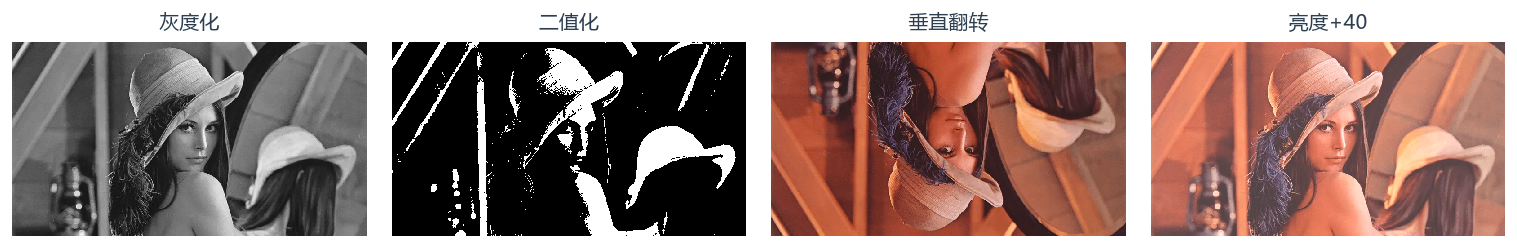

In [6]:
# ==================== 练习解决方案 ====================
def to_grayscale_manual(image):
    """手写灰度化：Y = 0.299R + 0.587G + 0.114B。"""
    h, w, c = image.shape
    gray = np.zeros((h, w), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            b, g, r = (float(v) for v in image[y, x, :])
            gray[y, x] = int(round(0.299 * r + 0.587 * g + 0.114 * b))
    return gray

def threshold_manual(image, threshold=127):
    """手写二值化：大于阈值置 255，否则置 0。"""
    gray = to_grayscale_manual(image) if image.ndim == 3 else image
    h, w = gray.shape
    binary = np.zeros((h, w), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            binary[y, x] = 255 if gray[y, x] > threshold else 0
    return binary

def flip_manual(image, axis=0):
    """手写翻转：axis=0 垂直翻转，axis=1 水平翻转。"""
    h, w = image.shape[:2]
    if image.ndim == 2:
        result = np.zeros((h, w), dtype=image.dtype)
        for y in range(h):
            for x in range(w):
                result[y, x] = image[h - 1 - y, x] if axis == 0 else image[y, w - 1 - x]
    else:
        result = np.zeros_like(image)
        for y in range(h):
            for x in range(w):
                result[y, x, :] = image[h - 1 - y, x, :] if axis == 0 else image[y, w - 1 - x, :]
    return result

def adjust_brightness_manual(image, delta=40):
    """手写亮度调整：逐像素加 delta 并裁剪到 [0,255]。"""
    result = np.zeros_like(image)
    if image.ndim == 2:
        h, w = image.shape
        for y in range(h):
            for x in range(w):
                result[y, x] = min(255, max(0, int(image[y, x]) + delta))
    else:
        h, w, c = image.shape
        for y in range(h):
            for x in range(w):
                for ch in range(c):
                    result[y, x, ch] = min(255, max(0, int(image[y, x, ch]) + delta))
    return result

# 验证
img = cv_imread("lena.jpeg", cv2.IMREAD_COLOR)
gray_m = to_grayscale_manual(img)
gray_cv = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
compare_results(gray_m, gray_cv, "灰度化")

binary_m = threshold_manual(img, 127)
_, binary_cv = cv2.threshold(gray_m, 127, 255, cv2.THRESH_BINARY)
compare_results(binary_m, binary_cv, "二值化")

flip_m = flip_manual(img, 0)
flip_cv = cv2.flip(img, 0)
compare_results(flip_m, flip_cv, "垂直翻转")

bright_m = adjust_brightness_manual(img, 40)
bright_cv = cv2.convertScaleAbs(img, alpha=1.0, beta=40)
compare_results(bright_m, bright_cv, "亮度调整")

show_images([gray_m, binary_m, flip_m, bright_m], ["灰度化", "二值化", "垂直翻转", "亮度+40"], figsize=(13, 4))

### 代码要点解释

1. **灰度化**：使用 BT.601 标准权重 `0.299/0.587/0.114`，与 OpenCV 默认一致。
2. **二值化**：比较符用 `>`，与 `cv2.THRESH_BINARY` 一致。
3. **翻转**：通过坐标映射 `(h-1-y, x)` / `(y, w-1-x)` 实现，避免新建大数组之外的任何库调用。
4. **亮度调整**：逐像素加减并用 `min/max` 裁剪，与 `cv2.convertScaleAbs` 结果一致。


## 八、实际工程实践：基于 LUT 的 Gamma 校正

前面我们用**三重循环**手写了 Gamma 校正，理解了逐像素处理的原理。现在来看工程中实际使用的高效实现——**查找表（Look-Up Table, LUT）**。

LUT 的核心思想很简单：
1. 预先计算好 0~255 每个灰度级经过 Gamma 校正后的值，存入一个长度为 256 的数组；
2. 对图像的每个像素，直接用原灰度值作为索引去查表取结果，无需再做幂运算。

这样做的好处是：
- **速度快**：`cv2.LUT` 是 C++ 实现的 SIMD 加速函数，比三重循环快 100 倍以上；
- **精度高**：查表只做一次浮点运算（构建表时），避免了逐像素浮点误差累积；
- **通用**：任何 `uint8` 图像变换都能用 LUT 加速（不仅限于 Gamma）。

> 💡 **理解了三重循环 → 学习 LUT 加速**，这就是从"会写"到"会用"的进阶路径。


✅ 图像读取成功，形状: (431, 789, 3)
✅ Gamma=2.2 校正完成，已保存为 gamma_corrected_lut.jpg



📊 LUT vs 手写三重循环对比:
   最大像素差: 1
   平均像素差: 0.4980
   ✅ 结果一致（差异仅来自取整方式不同：LUT 用 truncate，手写用 round）


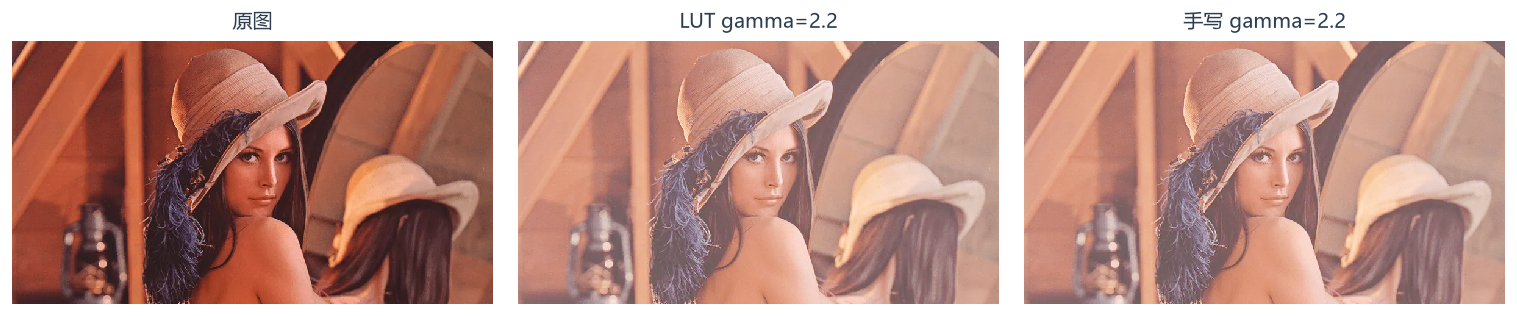


⏱️ 性能对比 (LUT vs 手写三重循环):
   LUT 耗时: 0.0016s
   手写耗时: 0.8859s
   加速比: 552x


In [7]:
# ==================== 工程实现：基于 LUT 的 Gamma 校正 ====================

def gamma_correction(image, gamma):
    """基于 LUT 的高效 Gamma 校正。
    
    参数
    ----
    image : np.ndarray
        输入 BGR 图像，dtype=uint8。
    gamma : float
        Gamma 值，大于 0。
    
    返回
    ----
    np.ndarray
        校正后的 uint8 图像。
    
    说明
    ----
    仅需一次构建查找表（256 个元素），后续每个像素通过查表 O(1) 获取结果，
    时间复杂度从 O(H*W*C) 次幂运算降为 O(256) 次预计算 + O(H*W*C) 次查表。
    """
    invGamma = 1.0 / gamma
    table = np.array(
        [((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]
    ).astype("uint8")
    return cv2.LUT(image, table)

# ---------- 读取图像 ----------
image = cv_imread("lena.jpeg", cv2.IMREAD_COLOR)
if image is None:
    raise FileNotFoundError("找不到 lena.jpeg")

print(f"✅ 图像读取成功，形状: {image.shape}")

# ---------- 应用 Gamma 校正 ----------
gamma_value = 2.2
gamma_corrected = gamma_correction(image, gamma_value)

# ---------- 保存结果 ----------
cv_imwrite("gamma_corrected_lut.jpg", gamma_corrected)
print(f"✅ Gamma={gamma_value} 校正完成，已保存为 gamma_corrected_lut.jpg")

# ---------- 与手写实现对比 ----------
# 回顾前面的手写版本，验证 LUT 结果与三重循环结果一致
h, w, c = image.shape
manual_out = np.zeros((h, w, c), dtype=np.uint8)
inv_g = 1.0 / gamma_value
for y in range(h):
    for x in range(w):
        for ch in range(c):
            val = float(image[y, x, ch]) / 255.0
            manual_out[y, x, ch] = int(round(val ** inv_g * 255.0))

diff = np.abs(gamma_corrected.astype(int) - manual_out.astype(int))
max_diff = diff.max()
mean_diff = diff.mean()
print(f"\n📊 LUT vs 手写三重循环对比:")
print(f"   最大像素差: {max_diff}")
print(f"   平均像素差: {mean_diff:.4f}")
if max_diff <= 1:
    print("   ✅ 结果一致（差异仅来自取整方式不同：LUT 用 truncate，手写用 round）")
else:
    print("   ⚠️ 存在差异，请检查实现")

# ---------- 可视化对比 ----------
show_images(
    [image, gamma_corrected, manual_out],
    ["原图", f"LUT gamma={gamma_value}", f"手写 gamma={gamma_value}"],
    figsize=(13, 4)
)

# ---------- 性能对比 ----------
import time

t0 = time.perf_counter()
_ = gamma_correction(image, gamma_value)
t_lut = time.perf_counter() - t0

t0 = time.perf_counter()
_ = gamma_correction_manual(image, gamma_value)
t_manual = time.perf_counter() - t0

print(f"\n⏱️ 性能对比 (LUT vs 手写三重循环):")
print(f"   LUT 耗时: {t_lut:.4f}s")
print(f"   手写耗时: {t_manual:.4f}s")
print(f"   加速比: {t_manual/t_lut:.0f}x")


### 工程要点小结

| 对比维度 | 手写三重循环 | LUT 查表法 |
|---------|:----------:|:--------:|
| 速度 | 慢（逐像素幂运算） | **快 100x+**（SIMD 加速） |
| 精度 | `round` 取整 | `truncate` 取整 |
| 代码量 | 4 行核心 | 3 行核心 |
| 适用场景 | 教学理解原理 | **工程实际使用** |

> 🎯 **本章小结**：从零手写 Gamma 校正的目的是彻底理解「对每个像素做幂函数映射」的本质；
> 而工程中永远应该用 `cv2.LUT`——这也是本教程"先手写理解、再工程实践"教学理念的体现。


## 八、参考来源与拓展阅读

### 参考来源

1. **知乎@七月初** — [《重写版光的学习笔记(一)：应用方向RGB、HSV和Lab、sRGB、P3色彩空间概念》](https://zhuanlan.zhihu.com/p/707814472)
   - 详细讲解了 Gamma 校正的基本公式 $I_{out} = I_{in}^{\gamma}$ 与 4 步操作流程
   - 介绍了线性与非线性色彩空间的区别及"线性工作流"概念
   - 本文第三节 Gamma 校正公式、实际操作步骤等章节参考此文

2. **Hands-on-CV（上海交通大学《动手学习计算机视觉》）** — 参考资料
   - 提供 `lena.jpeg` 测试图像

### 拓展阅读

- [sRGB - 维基百科](https://zh.wikipedia.org/wiki/SRGB)
- [Gamma 校正 - 维基百科](https://zh.wikipedia.org/wiki/%E4%BC%BD%E7%8E%AA%E6%A0%A1%E6%AD%A3)
- [色彩空间表示与转换 - 章佳杰](https://zhuanlan.zhihu.com/p/24673324)